In [1]:
# Put the project directory on the path to make sure we can import PyNitride
import sys, os
sys.path.append(os.path.abspath("../"))

In [2]:
%matplotlib notebook
import numpy as np
from scipy.linalg import norm
from pynitride import ParamDB, Material
from pynitride.bandstruct.kp import kp_6x6
from pynitride.bandstruct.reciprocal import generate_path
import matplotlib.pyplot as plt
from scipy import gradient
pmdb=ParamDB(units='neu')
to_units=pmdb.to_units
q,hbar,m_e,nm,kb=pmdb.get_constants("e,hbar,m_e,nm,k")
GaN=Material("GaN",pmdb=pmdb)

In [3]:
GaN=Material("GaN")
AlN=Material("AlN")
a0=GaN['lattice.a']
c0=GaN['lattice.c']
a=AlN['lattice.a']
C13oC33=GaN['stiffness.C13']/GaN['stiffness.C33']
st=(a-a0)/a0
sz=-2*C13oC33*st

In [4]:
kmax=4/nm
kvecs__t=generate_path(points=[[0,0,0],[kmax,0,0]],n=1000)
kvecs__z=generate_path(points=[[0,0,0],[0,0,kmax]],n=1000)

In [5]:
bs_r_n__z=kp_6x6(GaN,kvecs__z,[0,0,0],spin_orbit=False)
bs_r_n__t=kp_6x6(GaN,kvecs__t,[0,0,0],spin_orbit=False)

bs_r_so__z=kp_6x6(GaN,kvecs__z,[0,0,0],spin_orbit=True)
bs_r_so__t=kp_6x6(GaN,kvecs__t,[0,0,0],spin_orbit=True)

bs_s_n__z=kp_6x6(GaN,kvecs__z,[st,st,sz],spin_orbit=False)
bs_s_n__t=kp_6x6(GaN,kvecs__t,[st,st,sz],spin_orbit=False)

bs_s_so__z=kp_6x6(GaN,kvecs__z,[st,st,sz],spin_orbit=True)
bs_s_so__t=kp_6x6(GaN,kvecs__t,[st,st,sz],spin_orbit=True)

In [6]:
def plot_bs(k_z,bs_z,k_t,bs_t,label='',color='',new_fig=True):
    if new_fig:
        plt.figure(figsize=(6,6))
    plt.subplot(212)

    plt.plot(-k_z[:,2]*nm,bs_z[:,:6],color=color,label=label)
    plt.plot(k_t[:,0]*nm,bs_t[:,:6],color=color,label=label)
    plt.ylim(-.05,.0)
    plt.ylim(-.9,.1)
    plt.xlim(-2,2)
    plt.xlabel('            $\\leftarrow k_z, k_x\\rightarrow$   [1/nm]')
    #plt.xticks([-.15,.15])
    plt.ylabel('$E-E_{V0}$ [eV]')
    
    plt.subplot(211)
    plt.plot(-k_z[:,2]*nm,bs_z[:,6:],color=color,label=label)
    plt.plot(k_t[:,0]*nm,bs_t[:,6:],color=color,label=label)
    plt.xticks([])
    plt.ylabel('$E-E_{C0}$ [eV]')
    plt.xlim(-2,2)
    #plt.ylim(0,.05)
    plt.tight_layout()

In [7]:
plot_bs(kvecs__z,bs_r_n__z,kvecs__t,bs_r_n__t,color='b')
plot_bs(kvecs__z,bs_r_so__z,kvecs__t,bs_r_so__t,color='r',new_fig=False)
plt.title("Relaxed: SO versus no SO")

<IPython.core.display.Javascript object>

In [8]:
plot_bs(pseudo_k,bs_s_n,color='b')
plot_bs(pseudo_k,bs_s_so,color='r',new_fig=False)
plt.title("Strained: SO versus no SO")

NameError: name 'pseudo_k' is not defined

In [ ]:
plot_bs(pseudo_k,bs_r_so,color='b')
plot_bs(pseudo_k,bs_s_so,color='r',new_fig=False)
plt.title("Relaxed vs Strained, SO")

In [ ]:
plot_bs(pseudo_k,bs_r_n,color='b')
plot_bs(pseudo_k,bs_s_n,color='r',new_fig=False)
plt.title("Relaxed vs Strained, no SO")

In [11]:
from scipy.interpolate import interp1d

In [12]:
def DOS_of_one(k_z,bs1_z,k_t,bs1_t,E):
    kz=np.ravel(interp1d(np.ravel(bs1_z),np.ravel(k_z[:,2]),fill_value=0,bounds_error=False)(E))
    kt=np.ravel(interp1d(np.ravel(bs1_t),np.ravel(k_t[:,0]),fill_value=0,bounds_error=False)(E))
    N=1/(2*np.pi)**3 * 4/3 * np.pi * kz *kt**2
    DOS=gradient(N,E[1]-E[0])
    return E,DOS
    

In [13]:
bs_r_so__t.shape

(1000, 8)

<IPython.core.display.Javascript object>


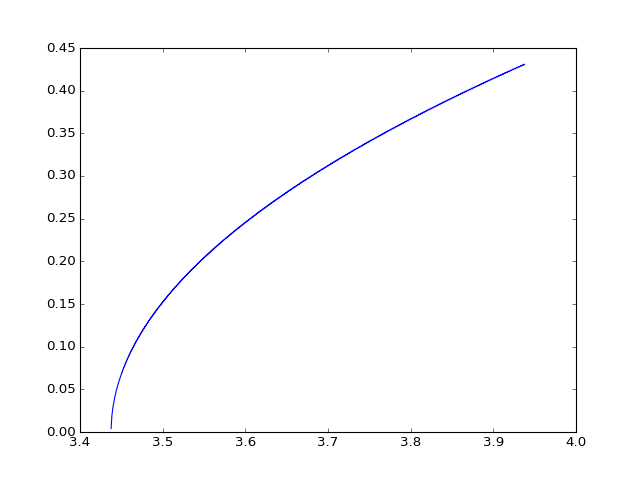

2.2637495068322954e+18

In [18]:
plt.figure()
Ec=bs_r_so__z[0,6]
E,DOS1=DOS_of_one(kvecs__z,bs_r_so__z[:,6],kvecs__t,bs_r_so__t[:,6],E=np.linspace(Ec,Ec+.5,5000))
E,DOS2=DOS_of_one(kvecs__z,bs_r_so__z[:,7],kvecs__t,bs_r_so__t[:,7],E=np.linspace(Ec,Ec+.5,5000))
DOS=DOS1+DOS2
plt.plot(E,DOS)
np.trapz(DOS*np.exp(-(E-Ec)/.026),E)*1e21

In [19]:
4.3e14 * 300**(3/2)

2.2343455417638518e+18

<IPython.core.display.Javascript object>


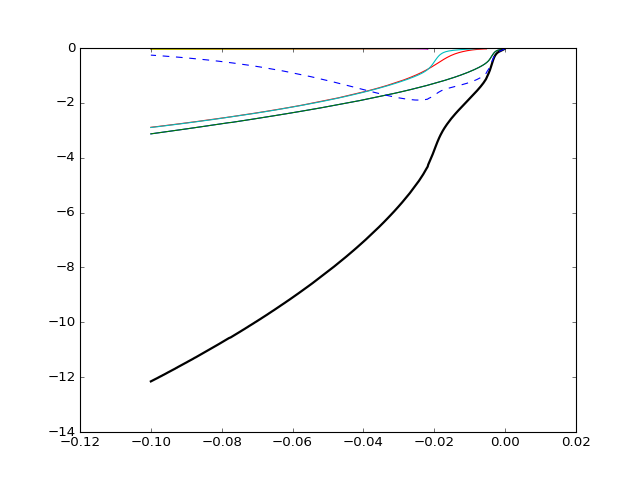

1.01735739272e+20


In [21]:
#E,DOS=DOS_of_one(kvecs__z,bs_r_so__z[:,6],kvecs__t,bs_r_so__t[:,6],E=np.linspace(3.4,3.8,1000))

Ev=bs_r_so__z[0,4]

plt.figure()
E,DOS1=DOS_of_one(kvecs__z,bs_r_so__z[:,5],kvecs__t,bs_r_so__t[:,4],E=np.linspace(0,-.1,1000))
plt.plot(E,DOS1)
E,DOS2=DOS_of_one(kvecs__z,bs_r_so__z[:,4],kvecs__t,bs_r_so__t[:,4],E=np.linspace(0,-.1,1000))
plt.plot(E,DOS2)
E,DOS3=DOS_of_one(kvecs__z,bs_r_so__z[:,3],kvecs__t,bs_r_so__t[:,3],E=np.linspace(0,-.1,1000))
plt.plot(E,DOS3)
E,DOS4=DOS_of_one(kvecs__z,bs_r_so__z[:,2],kvecs__t,bs_r_so__t[:,2],E=np.linspace(0,-.1,1000))
plt.plot(E,DOS4)
E,DOS5=DOS_of_one(kvecs__z,bs_r_so__z[:,1],kvecs__t,bs_r_so__t[:,1],E=np.linspace(0,-.1,1000))
plt.plot(E,DOS5)
E,DOS6=DOS_of_one(kvecs__z,bs_r_so__z[:,0],kvecs__t,bs_r_so__t[:,0],E=np.linspace(0,-.1,1000))
plt.plot(E,DOS6)
DOS=DOS1+DOS2+DOS3+DOS4+DOS5+DOS6
plt.plot(E,DOS,linewidth=2)

plt.plot(E,DOS*np.exp(-(Ev-E)/.026),'--')
Nv=np.trapz(DOS*np.exp(-(Ev-E)/.026),E)
print(Nv*1e21)

In [23]:
(2*np.pi*hbar**2)*(Nv/2)**(2/3)/(m_e*kb*300)

2.5425395379355695

In [41]:
8.9e15 * 300**(3/2)

4.6245756562089026e+19

In [42]:
2*(1.5*m_e*kb*300/(2*np.pi*hbar**2))**(3/2) *1e21

4.610084237621504e+19

In [15]:
def print_eff_mass(bs,k,p):
    n=len(k)
    for i in reversed(2*np.arange(3)):
        x=("E0={:7.3f}".format(bs[0,i]))
        x+=("     m={:7.3f}".format(-1/(2*m_e/hbar**2*(bs[p,i]-bs[0,i])/norm(k[p])**2)))
        x+=("     m'={:7.3f}".format(-hbar**2/(m_e*gradient(gradient(bs[:,i]))[p]/(norm(k[1,:])-norm(k[0]))**2)))
        print(x)
def plot_eff_mass(bs,k,i=4):
    #print(bs[:,i])
    m=-1/(2*m_e/hbar**2*(bs[:,i]-bs[0,i])/norm(k,axis=1)**2)
    mp=-hbar**2/(m_e*gradient(gradient(bs[:,i]))/(norm(k[1,:])-norm(k[0,:]))**2)
    #print(m)
    #print(mp)
    plt.plot(norm(k,axis=1),m)
    plt.plot(norm(k,axis=1),mp,'--')

<IPython.core.display.Javascript object>


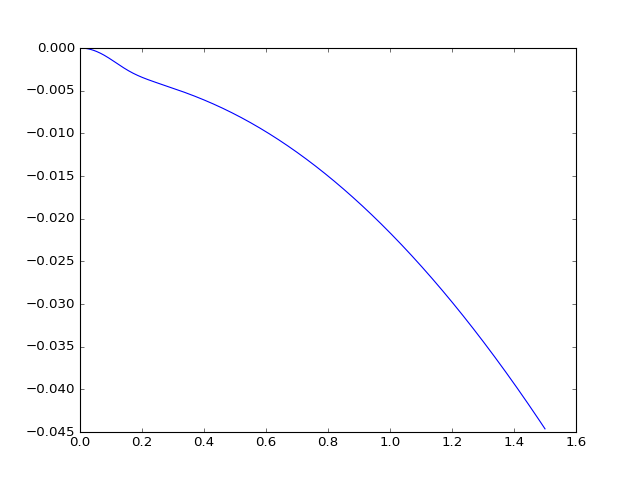

In [13]:
plt.figure()
plt.plot(norm(kvecs[499:],axis=1),(bs_r_so[499:][:,4]))

<IPython.core.display.Javascript object>


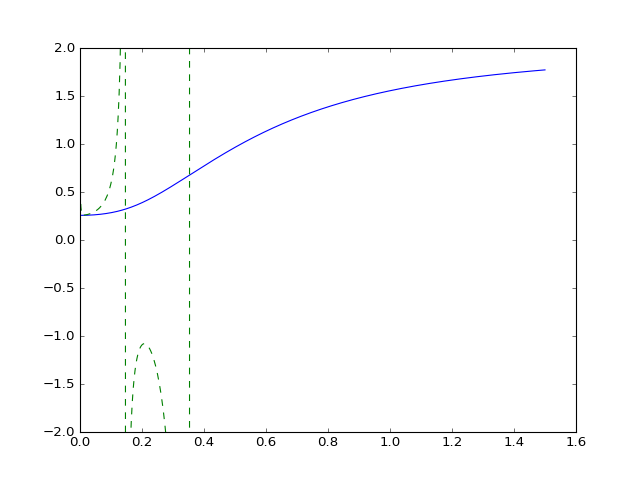

(-2, 2)

In [16]:
plt.figure()
plot_eff_mass(bs_s_so[499:],kvecs[499:])
plt.ylim(-2,2)

In [17]:
print("no SO")
print("z")
print_eff_mass(np.flipud(bs_r_n[:500]),np.flipud(kvecs[:500]),5)
print("t")
print_eff_mass((bs_r_n[499:]),(kvecs[499:]),5)
print("\n")
print("SO")
print("z")
print_eff_mass(np.flipud(bs_r_so[:500]),np.flipud(kvecs[:500]),5)
print("t")
print_eff_mass((bs_r_so[499:]),(kvecs[499:]),5)

no SO
z
E0=  0.000     m=  1.887     m'=  1.887
E0=  0.000     m=  1.887     m'=  1.887
E0= -0.010     m=  0.139     m'=  0.139
t
E0=  0.000     m=  2.000     m'=  2.000
E0=  0.000     m=  0.137     m'=  0.137
E0= -0.010     m=  2.273     m'=  2.273


SO
z
E0=  0.000     m=  1.887     m'=  1.887
E0= -0.005     m=  0.334     m'=  0.337
E0= -0.022     m=  0.211     m'=  0.209
t
E0=  0.000     m=  0.269     m'=  0.264
E0= -0.005     m=  0.054     m'=  0.322
E0= -0.022     m=  0.057     m'=  0.527


strained
---

In [41]:
print("no SO")
print("x")
print_eff_mass(np.flipud(bs_s_n[:500]),np.flipud(kvecs[:500]),5)
print("y")
print_eff_mass((bs_s_n[499:]),(kvecs[499:]),5)
print("\n")
print("SO")
print("x")
print_eff_mass(np.flipud(bs_s_so[:500]),np.flipud(kvecs[:500]),5)
print("y")
print_eff_mass((bs_s_so[499:]),(kvecs[499:]),5)

no SO
x
E0=  0.039     m=  1.887     m'=  1.887
E0=  0.039     m=  1.887     m'=  1.887
E0= -0.275     m=  0.139     m'=  0.139
y
E0=  0.039     m=  2.000     m'=  2.000
E0=  0.039     m=  0.137     m'=  0.137
E0= -0.275     m=  2.199     m'=  2.199


SO
x
E0=  0.039     m=  1.887     m'=  1.887
E0=  0.027     m=  1.871     m'=  1.871
E0= -0.281     m=  0.139     m'=  0.139
y
E0=  0.039     m=  0.257     m'=  0.260
E0=  0.027     m=  0.210     m'=  0.253
E0= -0.281     m=  0.764     m'=  2.186


strained at 100
---

In [43]:
print("SO")
print("x")
print_eff_mass(np.flipud(bs_s_so[:500]),np.flipud(kvecs[:500]),100)
print("y")
print_eff_mass((bs_s_so[499:]),(kvecs[499:]),100)

SO
x
E0=  0.039     m=  1.887     m'=  1.887
E0=  0.027     m=  1.872     m'=  1.877
E0= -0.281     m=  0.139     m'=  0.139
y
E0=  0.039     m=  0.569     m'= -3.216
E0=  0.027     m=  0.164     m'=  0.124
E0= -0.281     m=  1.983     m'=  2.089


In [23]:
bs_s_so[499][6]-bs_s_so[499][5]

3.6168123414269675

In [24]:
bs_r_so[499][6]-bs_r_so[499][5]

3.4376017699115038

In [25]:
bs_s_so[499][6]-bs_r_so[499][6]

0.21777057126334043

In [26]:
Material("AlN")["Eg"]

6.139999999999999

In [27]:
Material("AlN")["electron.DEc"]-(bs_s_so[499][6]-bs_r_so[499][6])

1.6172294287366593

AlN
===

In [28]:
aln_bs_r_so=kp_6x6(AlN,kvecs,[0,0,0],spin_orbit=True)

In [29]:
plot_bs(pseudo_k,aln_bs_r_so,color='r')
#plot_bs(pseudo_k,bs_r_so,color='r',new_fig=False)
plt.title("Relaxed: SO")# versus no SO")

<IPython.core.display.Javascript object>

In [30]:
print("SO")
print("x")
print_eff_mass(np.flipud(aln_bs_r_so[:500]),np.flipud(kvecs[:500]),100)
print("z")
print_eff_mass((aln_bs_r_so[499:]),(kvecs[499:]),100)

SO
x


NameError: name 'print_eff_mass' is not defined